In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df=pd.read_csv(r"pro.csv")

In [4]:
df

,study_hours,attendance,assignments,parent_education,previous_grade,final_score
0,2,65,5,low,55,50
1,3,70,6,medium,60,58
2,4,75,7,medium,65,63
3,5,80,8,high,70,72
4,6,85,9,high,75,80
5,1,60,4,low,50,45
6,7,90,10,high,85,88
7,3,72,6,medium,62,60
8,5,82,8,high,72,75
9,4,78,7,medium,68,66


In [5]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   study_hours  attendance  assignments parent_education  previous_grade  \
0            2          65            5              low              55   
1            3          70            6           medium              60   
2            4          75            7           medium              65   
3            5          80            8             high              70   
4            6          85            9             high              75   

   final_score  
0           50  
1           58  
2           63  
3           72  
4           80  


In [6]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   study_hours       12 non-null     int64 
 1   attendance        12 non-null     int64 
 2   assignments       12 non-null     int64 
 3   parent_education  12 non-null     object
 4   previous_grade    12 non-null     int64 
 5   final_score       12 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 704.0+ bytes
None


In [7]:
df["at_risk"] = df["final_score"].apply(lambda x: 1 if x < 60 else 0)

print("\nUpdated Dataset:")
print(df.head())


Updated Dataset:
   study_hours  attendance  assignments parent_education  previous_grade  \
0            2          65            5              low              55   
1            3          70            6           medium              60   
2            4          75            7           medium              65   
3            5          80            8             high              70   
4            6          85            9             high              75   

   final_score  at_risk  
0           50        1  
1           58        1  
2           63        0  
3           72        0  
4           80        0  


In [8]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   study_hours       12 non-null     int64 
 1   attendance        12 non-null     int64 
 2   assignments       12 non-null     int64 
 3   parent_education  12 non-null     object
 4   previous_grade    12 non-null     int64 
 5   final_score       12 non-null     int64 
 6   at_risk           12 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 800.0+ bytes
None


In [9]:
df["at_risk"] = df["final_score"].apply(lambda x: 1 if x < 60 else 0)

print("\nUpdated Dataset:")
print(df.head())


Updated Dataset:
   study_hours  attendance  assignments parent_education  previous_grade  \
0            2          65            5              low              55   
1            3          70            6           medium              60   
2            4          75            7           medium              65   
3            5          80            8             high              70   
4            6          85            9             high              75   

   final_score  at_risk  
0           50        1  
1           58        1  
2           63        0  
3           72        0  
4           80        0  


In [10]:

le = LabelEncoder()
df["parent_education"] = le.fit_transform(df["parent_education"])

In [11]:

X = df[["study_hours", "attendance", "assignments", 
        "parent_education", "previous_grade"]]

y = df["at_risk"]

In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\n--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))


--- Logistic Regression ---
Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [15]:

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("\n--- Decision Tree ---")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
print("Classification Report:\n", classification_report(y_test, y_pred_tree))



--- Decision Tree ---
Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [16]:

importances = tree_model.feature_importances_

feature_names = ["study_hours", "attendance", "assignments", 
                 "parent_education", "previous_grade"]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance_df)


Feature Importance:
            Feature  Importance
1        attendance         1.0
0       study_hours         0.0
2       assignments         0.0
3  parent_education         0.0
4    previous_grade         0.0


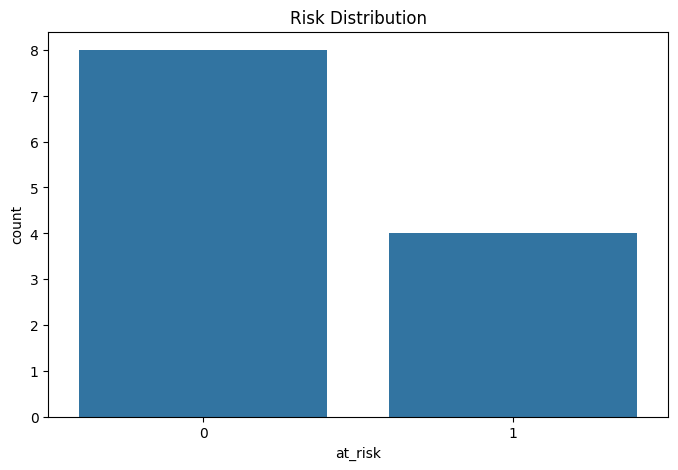

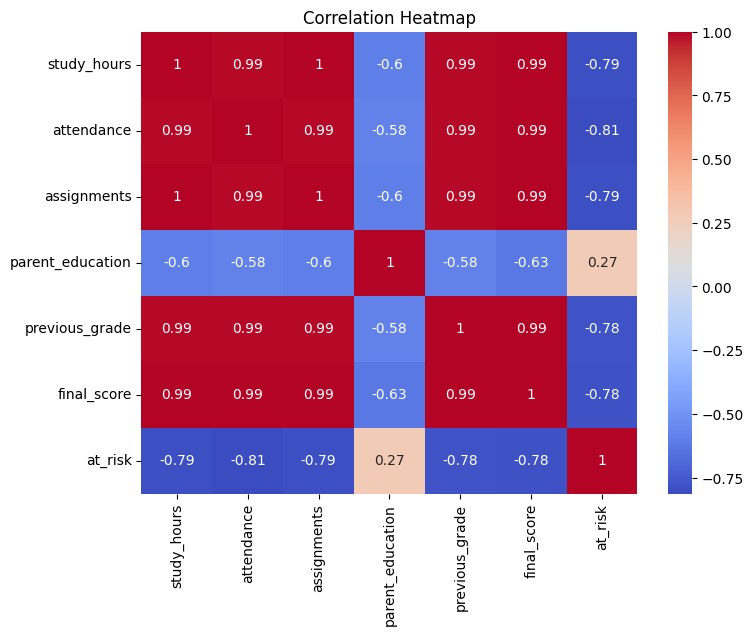

In [17]:

plt.figure(figsize=(8,5))
sns.countplot(x="at_risk", data=df)
plt.title("Risk Distribution")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()